In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import solvers
import sde
import dnnlib

torch.manual_seed(42)

In [44]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

class_labels = torch.randint(0, 1000, (16,), device="cuda")
# convert to one-hot as EDM2 expects
class_labels_onehot = torch.zeros(16, 1000, device="cuda")
class_labels_onehot.scatter_(1, class_labels.unsqueeze(1), 1)

model_fn = lambda x, sigma: model(x, sigma, )

In [45]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [46]:
sde_ = sde.EDMSDE(sigma_min=0.002, sigma_max=80).to("cuda")
rsde = sde_.get_reverse_sde(model_fn).to("cuda")
rsde.ode = True

In [47]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = sde_.sample_noise(x, t)[0]

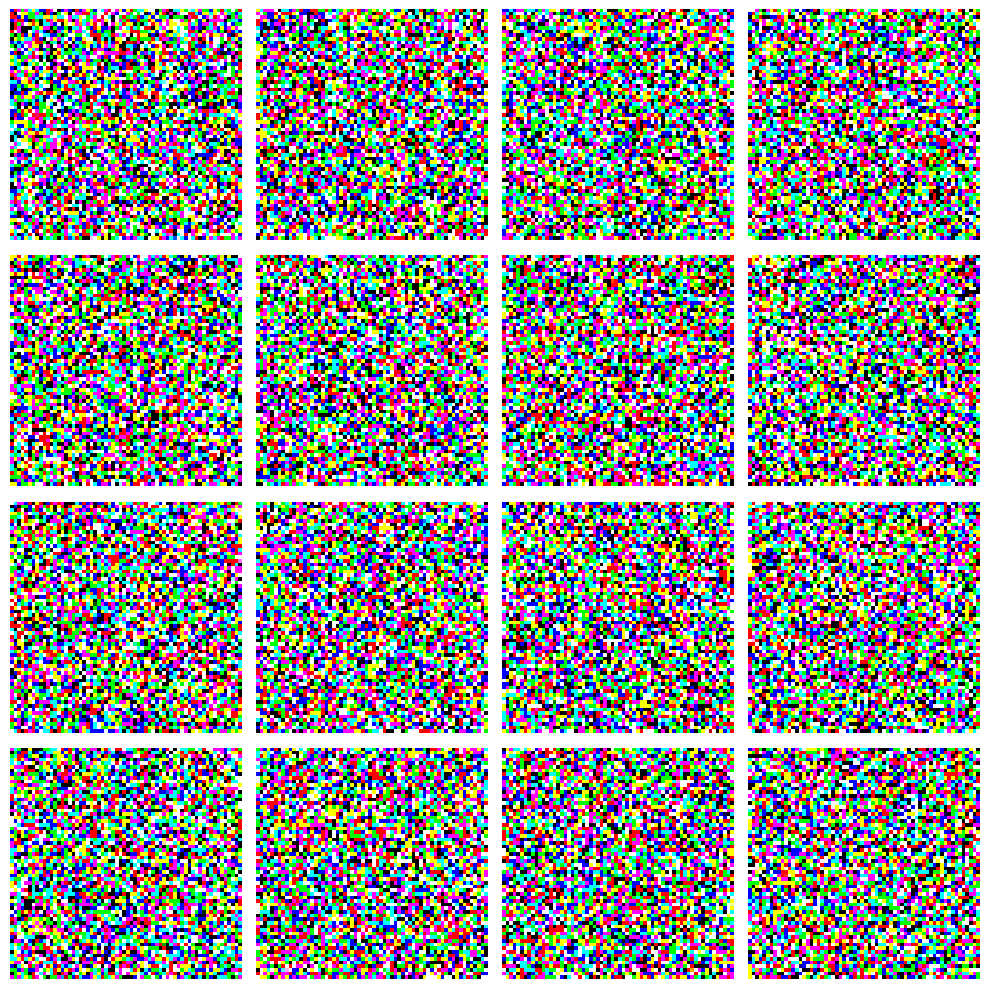

In [48]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [49]:
n_steps = 250
discretisation = torch.linspace(1, 0, n_steps)

em_solver = solvers.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone())

tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(False, device='cuda:0')
tensor(F

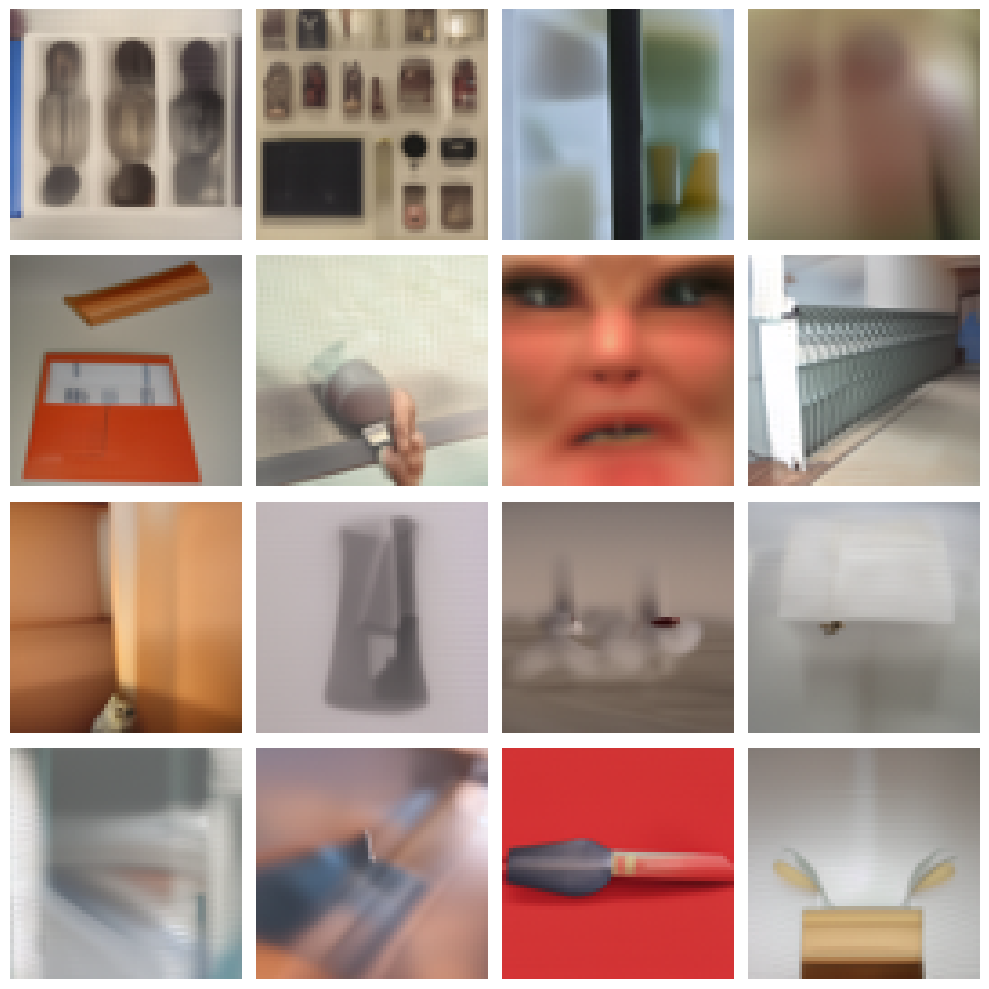

In [50]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [51]:
rsde.reset_nfe()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.101, 
    kp=0.09, 
    tau=0.4, 
    alpha=0.8,
    h_start=0.0005,
    max_decrease=0.7,
    max_increase=1.1,
    timeout=1000
).to("cuda")

x_pi = pi_solver.solve(noise.clone())

tensor(0., device='cuda:0')
T = 0.9994999766349792, h = -0.0005500000552274287
tensor(0., device='cuda:0')
T = 0.9989500045776367, h = -0.0006050000665709376
tensor(0., device='cuda:0')
T = 0.9983450174331665, h = -0.0006655000615864992
tensor(0., device='cuda:0')
T = 0.9976795315742493, h = -0.0007320501026697457
tensor(0., device='cuda:0')
T = 0.9969474673271179, h = -0.0008052551420405507
tensor(0., device='cuda:0')
T = 0.9961422085762024, h = -0.000885780667886138
tensor(0., device='cuda:0')
T = 0.9952564239501953, h = -0.0009743587579578161
tensor(0., device='cuda:0')
T = 0.994282066822052, h = -0.001071794657036662
tensor(0., device='cuda:0')
T = 0.9932102560997009, h = -0.0011669967789202929
tensor(0., device='cuda:0')
T = 0.9920432567596436, h = -0.0012528541265055537
tensor(0., device='cuda:0')
T = 0.9907903671264648, h = -0.0013310303911566734
tensor(0., device='cuda:0')
T = 0.9894593954086304, h = -0.0014015249907970428
tensor(0., device='cuda:0')
T = 0.9880578517913818, h =

In [52]:
rsde.nfe / 16

271.5

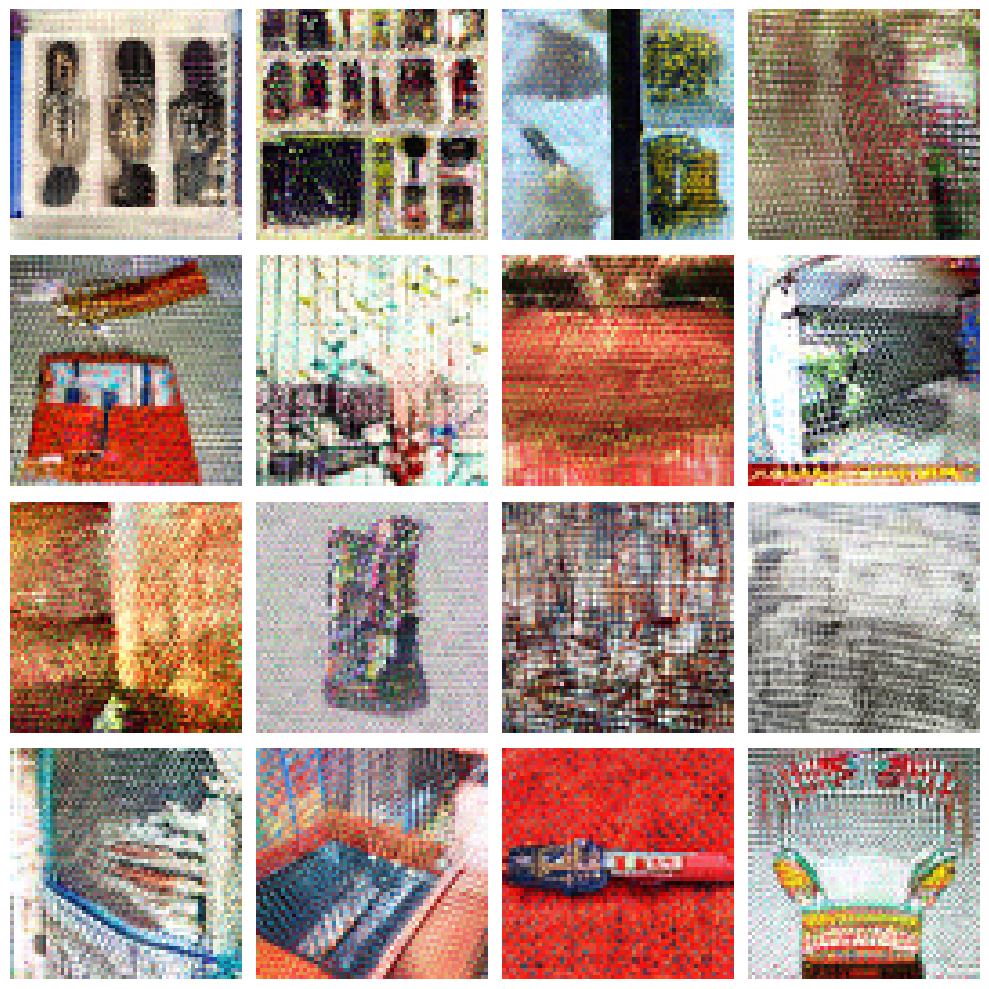

In [53]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())